In [2]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns',None)

ANALISIS DE DATOS

In [3]:
df_analisis = pd.read_csv("../Datos_Processed/df_unido.csv")
df_analisis.head()

,Id_cliente,Id_venta,Fecha_venta,Importe,Producto,Cantidad,Descuento,Canal,Region,Estado,Zona_envio,Metodo_envio,Peso_paquete,Rango_valor_pedido,Coste_envio,Id_canal,Id_producto,Nombre,Fecha_registro,Pais,Genero,Edad,Nivel_ingresos,Ciudad,Antiguedad
0,1,S16971,31/05/2017,214.46,Dispositivo G,5,10.0,En Linea,Norte,Cancelado,Zone 1,Standard,7.5,Medio,15.75,Tienda1,PROD-007,Steve Brown,16/02/2017,EE.UU,Hombre,50,Alto,Phoenix,9.0
1,1,S16302,24/01/2016,132.98,Dispositivo H,5,0.0,M-Commerce,Norte,Enviado,Zone 1,Express,7.5,Medio,20.25,Tienda2,PROD-008,Steve Brown,16/02/2017,EE.UU,Hombre,50,Alto,Phoenix,9.0
2,1,S33097,05/04/2016,253.95,Dispositivo B,6,0.0,En Linea,Oeste,Cancelado,Zone 4,Standard,9.0,Medio,15.30,Tienda1,PROD-002,Steve Brown,16/02/2017,EE.UU,Hombre,50,Alto,Phoenix,9.0
3,1,S39629,14/01/2021,348.60,Dispositivo E,3,0.0,En Linea,Sur,Pendiente,Zone 2,Standard,4.5,Medio,10.35,Tienda1,PROD-005,Steve Brown,16/02/2017,EE.UU,Hombre,50,Alto,Phoenix,9.0
4,1,S37229,07/11/2015,652.46,Dispositivo B,5,0.0,En Tienda,Sur,Completado,Zone 2,Pick-up,7.5,Alto,5.75,Tienda4,PROD-002,Steve Brown,16/02/2017,EE.UU,Hombre,50,Alto,Phoenix,9.0


In [4]:
# Reviso a modo de descripción los valores minimos, máximos, desv.estandar y percentiles de cada columna 
df_analisis.describe().T

,count,mean,std,min,25%,50%,75%,max
Id_cliente,51346.0,2499.979940,1446.080545,1.00,1246.0000,2503.00,3751.000,5000.00
Importe,51346.0,503.880262,285.380300,10.01,256.7725,504.01,749.745,999.99
Cantidad,51346.0,5.527441,2.847293,1.00,3.0000,6.00,8.000,10.00
Descuento,51346.0,3.056966,7.379398,0.00,0.0000,0.00,0.000,30.00
Peso_paquete,51346.0,8.132386,4.379664,1.50,4.5000,7.50,12.000,15.00
Coste_envio,51346.0,12.062920,6.095821,1.75,7.5000,10.75,15.750,35.00
Edad,51346.0,49.217174,17.813430,18.00,34.0000,49.00,64.000,80.00
Antiguedad,51346.0,7.805749,2.045088,4.00,6.0000,8.00,10.000,11.00


In [5]:
# Reviso los estados de los pedidos, cantidad total de productos e importes

df = pd.DataFrame(df_analisis)

# Agrupar por estado
resultado = (
    df.groupby("Estado")
      .agg(
          unidades=("Cantidad", "sum"),
          importe_total=("Importe", "sum"),
          coste=("Coste_envio", "sum")
      )
      .reset_index()
      .rename(columns={"Estado": "estado_pedido"})
)

# Crear la columna beneficio
resultado["beneficio"] = resultado["importe_total"] - resultado["coste"]

# Crear la columna margen de beneficio en %

resultado["margen_%"] = (
    (resultado["beneficio"] / resultado["importe_total"]) * 100
).round(2)


print(resultado)


  estado_pedido  unidades  importe_total     coste   beneficio  margen_%
0     Cancelado     71388     6484990.74  155744.3  6329246.44     97.60
1    Completado     71759     6511714.51  156715.1  6354999.41     97.59
2       Enviado     70432     6466970.17  153967.3  6313002.87     97.62
3     Pendiente     70233     6408560.53  152956.0  6255604.53     97.61


1. ANALISIS DE CANTIDAD DE VENTAS POR AÑO

In [6]:
# Se analizan las ventas de todos los productos en todos los estados por años

df_productos = df_analisis[df_analisis['Estado'].isin(['Completado', 'Enviado','Cancelado', 'Pendiente'])].copy()


In [7]:
# Compruebo que la fecha es de formato DataTime y extraigo el año

df_productos['Fecha_venta'] = pd.to_datetime(df_productos['Fecha_venta'], errors='coerce')
df_productos['Año'] = df_productos['Fecha_venta'].dt.year


C:\Users\dgjer\AppData\Local\Temp\ipykernel_16192\1200057205.py:3: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_productos['Fecha_venta'] = pd.to_datetime(df_productos['Fecha_venta'], errors='coerce')


In [8]:
# Agrupo por año para obtener ventas totales de productos y el importe total por año

df_ventas_por_año = (
    df_productos.groupby('Año')
    .agg(
        Cantidad_Total=('Cantidad', 'sum'),
        Importe_Total=('Importe', 'sum'),
    )
    .reset_index()
)

total_cantidad = df_ventas_por_año['Cantidad_Total'].sum()

df_ventas_por_año['% del Total'] = (
    df_ventas_por_año['Cantidad_Total'] / total_cantidad * 100
).round(2)

df_ventas_por_año


,Año,Cantidad_Total,Importe_Total,% del Total
0,2015,35889,3273780.42,12.65
1,2016,35510,3249243.89,12.51
2,2017,34741,3263464.66,12.24
3,2018,35179,3202512.87,12.40
4,2019,36008,3227754.43,12.69
5,2020,34676,3121695.03,12.22
6,2021,36127,3319767.60,12.73
7,2022,35682,3214017.05,12.57


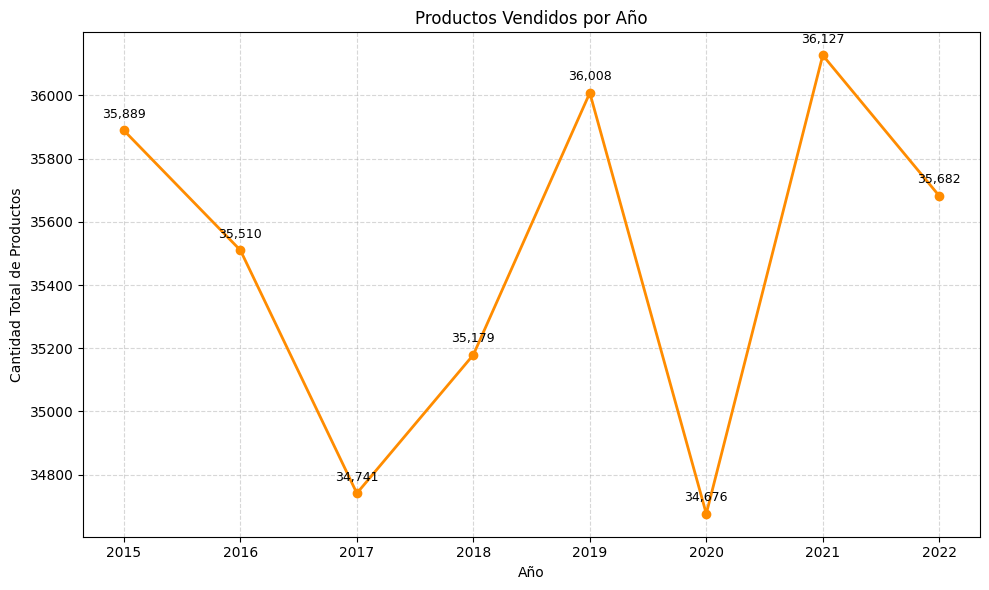

In [9]:
# Creo un grafico de lineas para visualizar el progreso de productos vendidos por Año.

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(
    df_ventas_por_año['Año'],
    df_ventas_por_año['Cantidad_Total'],
    marker='o',
    linewidth=2,
    color='darkorange'
)

for x, y in zip(df_ventas_por_año['Año'], df_ventas_por_año['Cantidad_Total']):
    plt.text(
        x,
        y + 40,         
        f"{y:,}",
        ha='center',
        fontsize=9
    )

plt.title('Productos Vendidos por Año')
plt.xlabel('Año')
plt.ylabel('Cantidad Total de Productos')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



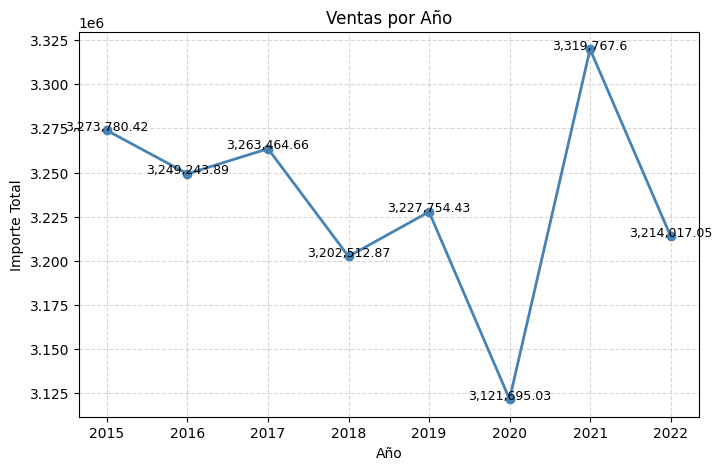

In [10]:
# Creo un grafico de lineas para visualizar el progreso de ventas por Año.

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    df_ventas_por_año['Año'],
    df_ventas_por_año['Importe_Total'],
    marker='o',
    linewidth=2,
    color='steelblue'
)

for x, y in zip(df_ventas_por_año['Año'], df_ventas_por_año['Importe_Total']):
    plt.text(
        x,
        y + 45,         
        f"{y:,}",
        ha='center',
        fontsize=9
    )

plt.title('Ventas por Año')
plt.xlabel('Año')
plt.ylabel('Importe Total')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


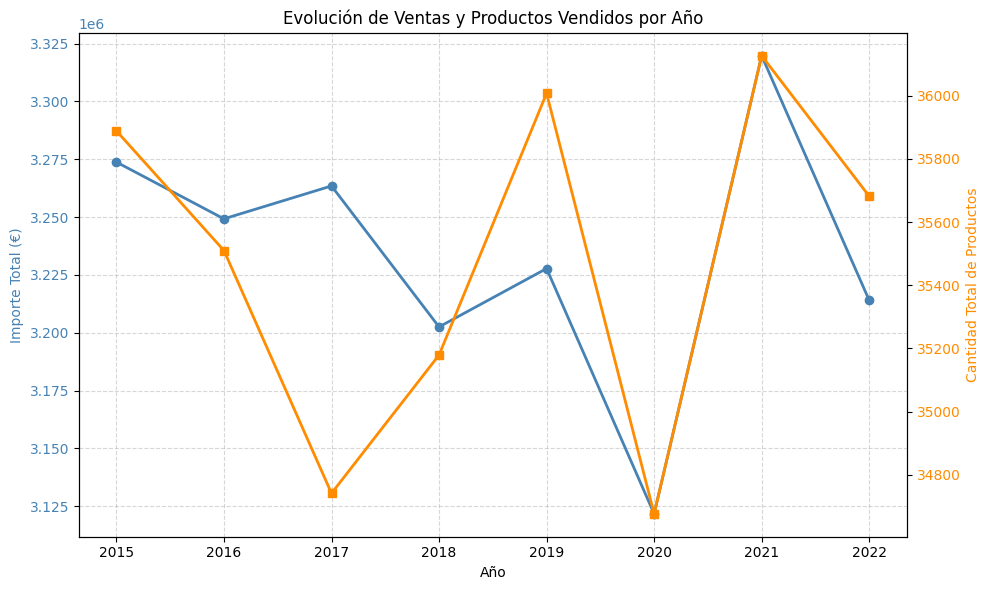

In [11]:
# Creo un grafico de lineas para visualizar el progreso de ventas y productos vendidos por Año.

import matplotlib.pyplot as plt


años = df_ventas_por_año['Año']
cantidades = df_ventas_por_año['Cantidad_Total']
importes = df_ventas_por_año['Importe_Total']


fig, ax1 = plt.subplots(figsize=(10,6))


color1 = 'steelblue'
ax1.set_xlabel('Año')
ax1.set_ylabel('Importe Total (€)', color=color1)
ax1.plot(años, importes, marker='o', linewidth=2, color=color1, label='Importe Total')
ax1.tick_params(axis='y', labelcolor=color1)


ax2 = ax1.twinx()  
color2 = 'darkorange'
ax2.set_ylabel('Cantidad Total de Productos', color=color2)
ax2.plot(años, cantidades, marker='s', linewidth=2, color=color2, label='Cantidad Total')
ax2.tick_params(axis='y', labelcolor=color2)


plt.title('Evolución de Ventas y Productos Vendidos por Año')
ax1.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Tanto en productos vendidos (36.127 unidades) como en importe total (3.319.767,60 €), 2021 es el pico absoluto.
El aumento de ventas en 2021 es más pronunciado que el aumento de productos.

Esto sugiere que el precio medio por producto subió, o que se vendieron más productos de mayor valor.

Conclusión:  
2021 no solo vendió más unidades, sino que cada unidad generó más dinero. Es un año de mejor mix de productos o incremento de precios.

2. ANALISIS POR TIPO DE PRODUCTOS

In [12]:
# Creo un DataFrame con los productos mas vendidos por año, junto con la cantidad total de unidades vendidas y el importe total de ventas.

df_ventas_por_año = (
    df_productos.groupby('Año')
    .agg(
        Cantidad_Total=('Cantidad', 'sum'),
        Importe_Total=('Importe', 'sum'),
        Producto=('Producto', 'first')
    )
    
)

df_ventas_por_año = df_ventas_por_año.reset_index()

df_ventas_por_año

,Año,Cantidad_Total,Importe_Total,Producto
0,2015,35889,3273780.42,Dispositivo B
1,2016,35510,3249243.89,Dispositivo H
2,2017,34741,3263464.66,Dispositivo G
3,2018,35179,3202512.87,Dispositivo I
4,2019,36008,3227754.43,Dispositivo A
5,2020,34676,3121695.03,Dispositivo I
6,2021,36127,3319767.60,Dispositivo E
7,2022,35682,3214017.05,Dispositivo B


In [13]:
# Reviso cual ha sido el producto mas vendido en cada año

import pandas as pd
import matplotlib.pyplot as plt

# Cantidad vendida por producto y año
ventas_producto_año = (
    df_productos
    .groupby(['Año', 'Producto'])['Cantidad']
    .sum()
    .reset_index()
)

# Obtener el producto con mayor cantidad en cada año
top_producto_año = ventas_producto_año.loc[
    ventas_producto_año.groupby('Año')['Cantidad'].idxmax()
]

top_producto_año = top_producto_año.sort_values('Año')

print(top_producto_año)

     Año       Producto  Cantidad
3   2015  Dispositivo D      3793
11  2016  Dispositivo B      3900
27  2017  Dispositivo H      3792
39  2018  Dispositivo J      3708
42  2019  Dispositivo C      3948
58  2020  Dispositivo I      3617
69  2021  Dispositivo J      3802
78  2022  Dispositivo I      3772


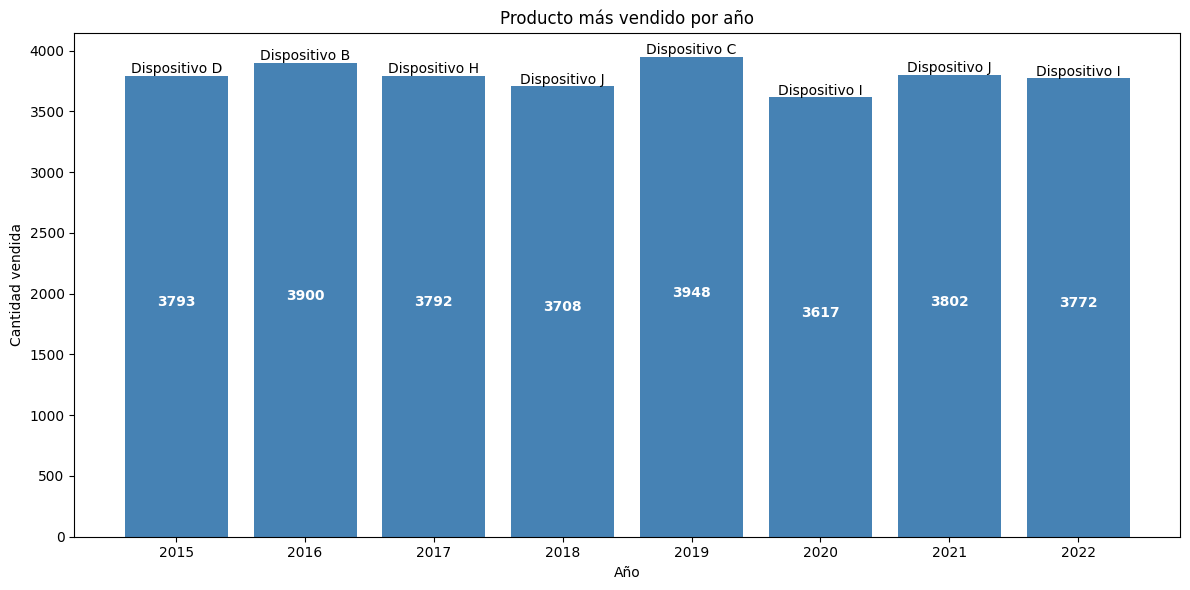

In [14]:
# Creo un gráfico de barras para visualizar los productos mas vendidos por año

plt.figure(figsize=(12, 6))

bars = plt.bar(
    top_producto_año['Año'].astype(str),
    top_producto_año['Cantidad'],
    color='steelblue'
)

plt.title('Producto más vendido por año')
plt.xlabel('Año')
plt.ylabel('Cantidad vendida')

# Etiqueta con el nombre del producto
for bar, producto in zip(bars, top_producto_año['Producto']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 20,
        producto,
        ha='center',
        fontsize=10
    )

# Creo valores encima de columnas

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()/2,
        f'{int(bar.get_height())}',
        ha='center',
        color='white',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Conclusión: El producto mas vendido en los años ha sido Dispositivo C en el 2019 (3.948 unidades).

3. ANALISIS POR TIENDAS

In [15]:
# Creo un DataFrame con las tiendas que más han vendido, junto con la cantidad total de unidades vendidas y el importe total de ventas.

df_ventas_por_tienda = (
    df_productos.groupby('Id_canal')
    .agg(
        Cantidad_Total=('Cantidad', 'sum'),
        Importe_Total=('Importe', 'sum'),
    )
    .sort_values('Cantidad_Total', ascending=False)
)
df_ventas_por_tienda

,Cantidad_Total,Importe_Total
Id_canal,,
Tienda3,71317,6482328.61
Tienda1,71093,6485323.82
Tienda2,71053,6436537.66
Tienda4,70349,6468045.86


In [16]:
# Reviso la venta de productos por tienda y año
df_ventas_por_tienda_año = (
    df_productos.groupby(['Id_canal', 'Año'])
    .agg(
        Cantidad_Total=('Cantidad', 'sum'),
        Importe_Total=('Importe', 'sum'),
    )
    .reset_index()
    .sort_values(['Id_canal', 'Año'])
)

df_ventas_por_tienda_año


,Id_canal,Año,Cantidad_Total,Importe_Total
0,Tienda1,2015,9239,851906.79
1,Tienda1,2016,8916,823578.76
2,Tienda1,2017,8714,790861.60
3,Tienda1,2018,8976,802808.01
4,Tienda1,2019,8874,777862.19
5,Tienda1,2020,8288,756141.11
6,Tienda1,2021,9454,894925.10
7,Tienda1,2022,8632,787240.26
8,Tienda2,2015,8782,777970.26
9,Tienda2,2016,8835,794373.07


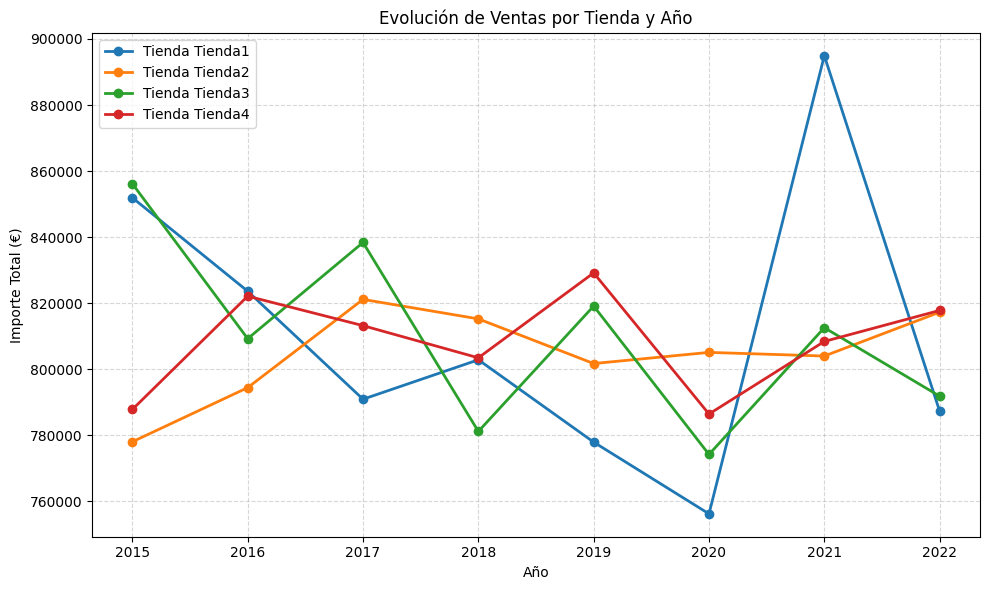

In [17]:
# Creo un gráfico para mostrar la evolución de ventas por tienda y año

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for canal in df_ventas_por_tienda_año['Id_canal'].unique():
    df_temp = df_ventas_por_tienda_año[df_ventas_por_tienda_año['Id_canal'] == canal]
    plt.plot(
        df_temp['Año'],
        df_temp['Importe_Total'],
        marker='o',
        linewidth=2,
        label=f'Tienda {canal}'
    )

plt.title('Evolución de Ventas por Tienda y Año')
plt.xlabel('Año')
plt.ylabel('Importe Total (€)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


Conclusión: 
Tienda 1 es el canal que más ventas ha realizado en el año 2021 (894925.10 €)
Tienda 2 es el canal con ventas más estables, sin picos bruscos altos y bajos.
Tienda 3 es el canal con tendencia de ventas moderada y sin caidas bruscas.
Tienda 4 es el canal con ventas volatiles y con caidas y subidas mas pronunciadas.

4. ANALISIS POR CANAL

In [18]:
# Creo un DataFrame con las ventas totales por canal, junto con la cantidad total de unidades vendidas y el importe total de ventas.

df_ventas_por_canal = (
    df_productos.groupby('Canal')
    .agg(
        Cantidad_Total=('Cantidad', 'sum'),
        Importe_Total=('Importe', 'sum'),
    )
    .sort_values('Cantidad_Total', ascending=False)
)
df_ventas_por_canal

,Cantidad_Total,Importe_Total
Canal,,
Minorista,71317,6482328.61
En Linea,71093,6485323.82
M-Commerce,71053,6436537.66
En Tienda,70349,6468045.86


Conclusión: El canal  con mayor importe de ventas realizadas ha sido el canal Minorista (6482328.61 €).

5. ANALISIS POR METODO DE ENVIO

In [19]:
# Creo un DataFrame con las ventas totales por método de envío, junto con la cantidad total de unidades vendidas y el importe total de ventas.


df_ventas_por_metodo_envio = (
    df_productos.groupby('Metodo_envio')
    .agg(
        Cantidad_Total=('Cantidad', 'sum'),
        Importe_Total=('Importe', 'sum'),
    )
    .sort_values('Cantidad_Total', ascending=False)
    .reset_index()
)

df_ventas_por_metodo_envio


,Metodo_envio,Cantidad_Total,Importe_Total
0,Local,71317,6482328.61
1,Standard,71093,6485323.82
2,Express,71053,6436537.66
3,Pick-up,70349,6468045.86


Conclusión: El metodo de envio de productos mas utilizado ha sido el envio Local (71317 unidades y 6482328.61 €)

6. ANALISIS POR VALOR DE PEDIDO


In [20]:
# Creo un DataFrame con las ventas totales segun el rango de valor de pedido, junto con la cantidad total de unidades vendidas y el importe total de ventas.


df_ventas_por_valor_pedido = (
    df_productos.groupby('Rango_valor_pedido')
    .agg(
        Cantidad_Total=('Cantidad', 'sum'),
        Importe_Total=('Importe', 'sum'),
    )
    .sort_values('Cantidad_Total', ascending=False)
    .reset_index()
)

df_ventas_por_valor_pedido

    

,Rango_valor_pedido,Cantidad_Total,Importe_Total
0,Alto,142829,19394214.02
1,Medio,114782,6218678.23
2,Bajo,26201,259343.70


Conclusión: Los productos de alto valor han sido los mas vendidos (19394214.02 €)

7. ANALISIS POR COSTE DE ENVIO

In [21]:
# Creo un DataFrame con los productos con mayor coste de envio por año, junto con la cantidad total de unidades vendidas y el importe total de ventas.

# Creo un valor para obtener el producto con mayor coste de envío por año
idx = df_productos.groupby('Año')['Coste_envio'].idxmax()

df_ventas_por_coste_envio = df_productos.loc[idx, ['Año', 'Producto', 'Cantidad', 'Coste_envio']]
df_ventas_por_coste_envio = df_ventas_por_coste_envio.rename(columns={
    'Cantidad': 'Cantidad_Total',
    'Coste_envio': 'Coste_Total'
})

df_ventas_por_coste_envio


,Año,Producto,Cantidad_Total,Coste_Total
27819,2015,Dispositivo B,10,35.0
4388,2016,Dispositivo J,10,35.0
19979,2017,Dispositivo A,9,33.5
10776,2018,Dispositivo F,10,33.0
13392,2019,Dispositivo B,10,35.0
37982,2020,Dispositivo G,10,35.0
16367,2021,Dispositivo J,10,35.0
19558,2022,Dispositivo G,9,33.5


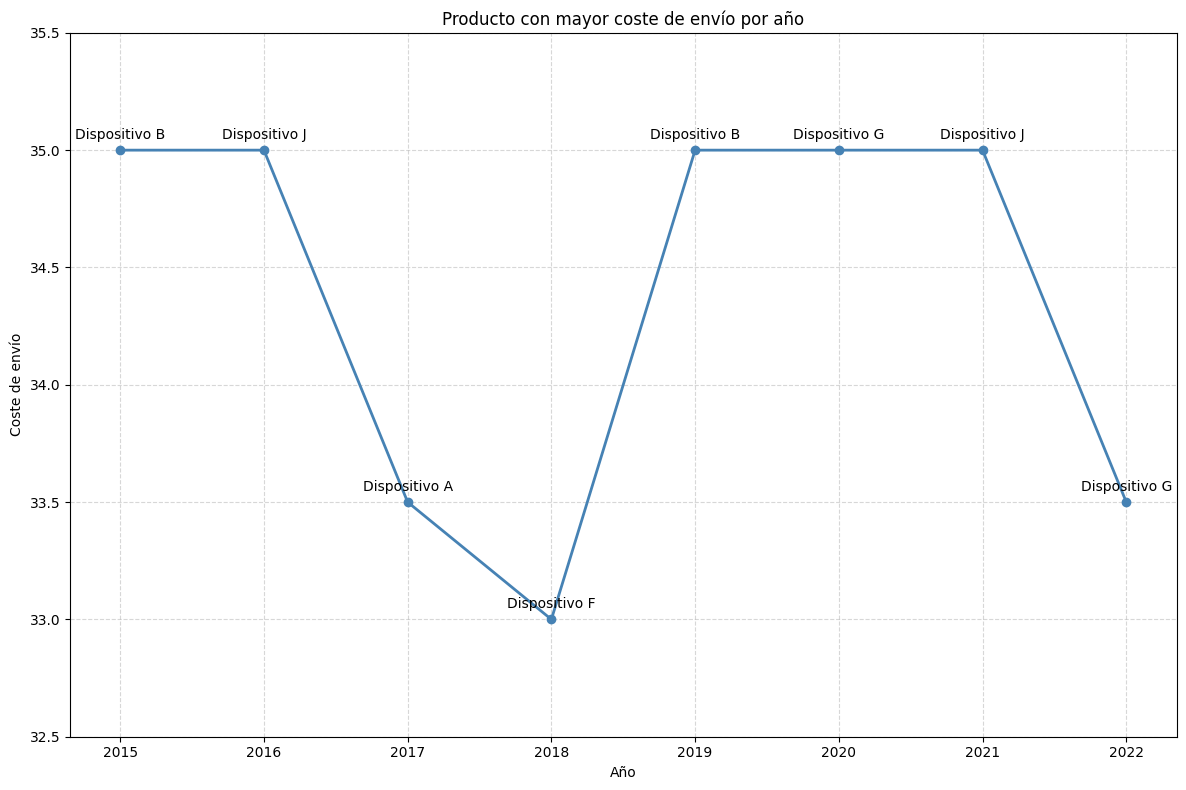

In [22]:
# Creo un grafico de lineas para mostrar los productos con más costes de envio por año

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.plot(
    df_ventas_por_coste_envio['Año'],
    df_ventas_por_coste_envio['Coste_Total'],
    marker='o',
    linewidth=2,
    color='steelblue'
)

plt.xlabel('Año')
plt.ylabel('Coste de envío')
plt.title('Producto con mayor coste de envío por año')
plt.grid(True, linestyle='--', alpha=0.5)

# Más espacio para las etiquetas
plt.ylim(
    df_ventas_por_coste_envio['Coste_Total'].min() - 0.5,
    df_ventas_por_coste_envio['Coste_Total'].max() + 0.5
)

for x, y, producto in zip(
    df_ventas_por_coste_envio['Año'],
    df_ventas_por_coste_envio['Coste_Total'],
    df_ventas_por_coste_envio['Producto']
):
    plt.annotate(
        producto,
        (x, y),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center'
    )

plt.tight_layout()
plt.show()

Conclusión: Los productos con costes de envios más altos (35€) entre el 2015 y 2022 han sido los dispositivos B, J, G.

8. ANALISIS DEMOGRÁFICO

8.1 Analisis por Páis

In [23]:
# Creo un DataFrame para mostar los paises donde más productos se han vendido

df_ventas_por_pais = (
    df_productos.groupby('Pais')
    .agg(
        Cantidad_Total=('Cantidad', 'sum'),
        Importe_Total=('Importe', 'sum'),
    )
    .sort_values('Cantidad_Total', ascending=False)
    .reset_index()
)

df_ventas_por_pais

,Pais,Cantidad_Total,Importe_Total
0,EE.UU,131992,12039247.88
1,Reino Unido,26624,2452641.47
2,Alemania,26607,2403910.35
3,España,26074,2393514.56
4,Canada,24594,2177326.69
5,Australia,24346,2261538.69
6,Francia,23575,2144056.31


In [24]:
df_ventas_por_pais = df_ventas_por_pais.sort_values('Importe_Total', ascending=True)
df_ventas_por_pais

,Pais,Cantidad_Total,Importe_Total
6,Francia,23575,2144056.31
4,Canada,24594,2177326.69
5,Australia,24346,2261538.69
3,España,26074,2393514.56
2,Alemania,26607,2403910.35
1,Reino Unido,26624,2452641.47
0,EE.UU,131992,12039247.88


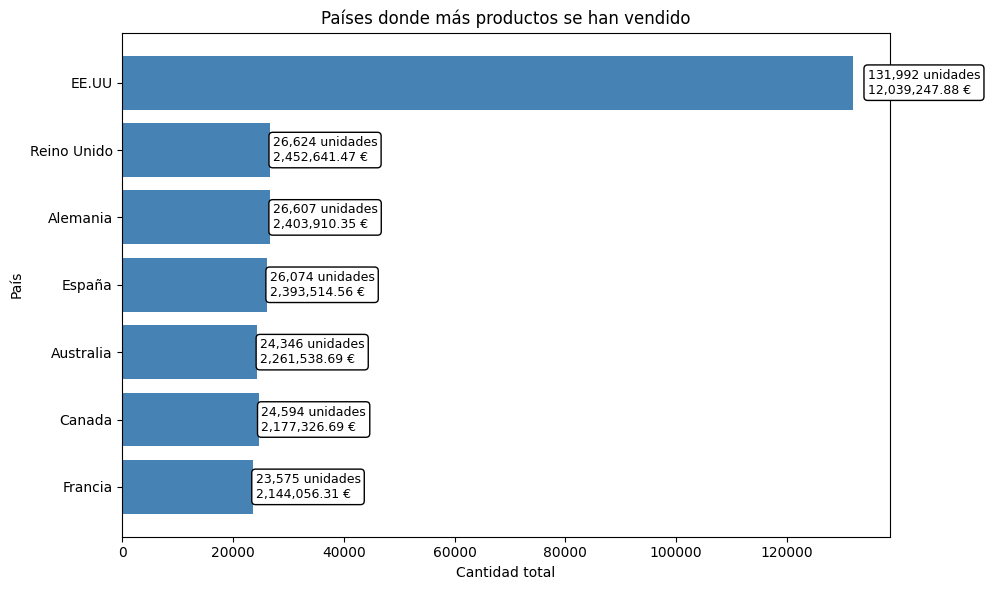

In [25]:
# Creo un grafico de barras para mostrar los resultados

plt.figure(figsize=(10,6))

plt.barh(
    df_ventas_por_pais['Pais'],
    df_ventas_por_pais['Cantidad_Total'],
    color='steelblue'
)

plt.xlabel('Cantidad total')
plt.ylabel('País')
plt.title('Países donde más productos se han vendido')


for pais, cantidad, importe in zip(
    df_ventas_por_pais['Pais'],
    df_ventas_por_pais['Cantidad_Total'],
    df_ventas_por_pais['Importe_Total']
):
    etiqueta = f"{cantidad:,} unidades\n{importe:,.2f} €"
    
    plt.text(
        cantidad + (cantidad * 0.02),   
        pais,
        etiqueta,
        va='center',
        fontsize=9,
        color='black',
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
    )

plt.tight_layout()
plt.show()


8.2. Analisis por Región

In [26]:
# Creo un DataFrame para ver los paises y sus regiones con la cantidad e importe de productos vendidos
df_ventas_por_pais_region = (
    df_productos.groupby(['Pais', 'Region'])
    .agg(
        Cantidad_Total=('Cantidad', 'sum'),
        Importe_Total=('Importe', 'sum')
    )
    .reset_index()
    .sort_values(['Pais', 'Cantidad_Total'], ascending=[True, False])
)


df_ventas_por_pais_region

,Pais,Region,Cantidad_Total,Importe_Total
3,Alemania,Sur,6779,617234.21
1,Alemania,Norte,6739,593098.61
0,Alemania,Este,6587,586642.52
2,Alemania,Oeste,6502,606935.01
7,Australia,Sur,6301,581499.99
5,Australia,Norte,6182,570610.19
4,Australia,Este,6030,564919.52
6,Australia,Oeste,5833,544508.99
11,Canada,Sur,6224,556906.20
10,Canada,Oeste,6222,547463.84


In [27]:
# 1. Creo un DataFrame para ver los paises y sus regiones con la cantidad e importe de productos vendidos

df_ventas_por_pais_region = (
    df_productos.groupby(['Pais', 'Region'])
    .agg(
        Cantidad_Total=('Cantidad', 'sum'),
        Importe_Total=('Importe', 'sum')
    )
    .reset_index()
)

# 2. Ordeno los países por mayor cantidad total
totales_pais = (
    df_ventas_por_pais_region.groupby('Pais')['Cantidad_Total']
    .sum()
    .sort_values(ascending=False)
)

df_ventas_por_pais_region['Pais'] = pd.Categorical(
    df_ventas_por_pais_region['Pais'],
    categories=totales_pais.index,
    ordered=True
)

# 3. Ordeno las regiones dentro de cada país por mayor cantidad
df_ventas_por_pais_region = df_ventas_por_pais_region.sort_values(
    ['Pais','Cantidad_Total'],
    ascending=[True, False]
)

df_ventas_por_pais_region


,Pais,Region,Cantidad_Total,Importe_Total
14,EE.UU,Oeste,33573,3023587.25
13,EE.UU,Norte,32964,2967348.54
12,EE.UU,Este,32803,3051810.80
15,EE.UU,Sur,32652,2996501.29
25,Reino Unido,Norte,6907,623294.66
26,Reino Unido,Oeste,6785,636908.30
24,Reino Unido,Este,6635,613222.09
27,Reino Unido,Sur,6297,579216.42
3,Alemania,Sur,6779,617234.21
1,Alemania,Norte,6739,593098.61


In [28]:
df_ventas_por_pais_region = df_ventas_por_pais_region.sort_values(
    ['Pais','Cantidad_Total'],
    ascending=[False,True]
)

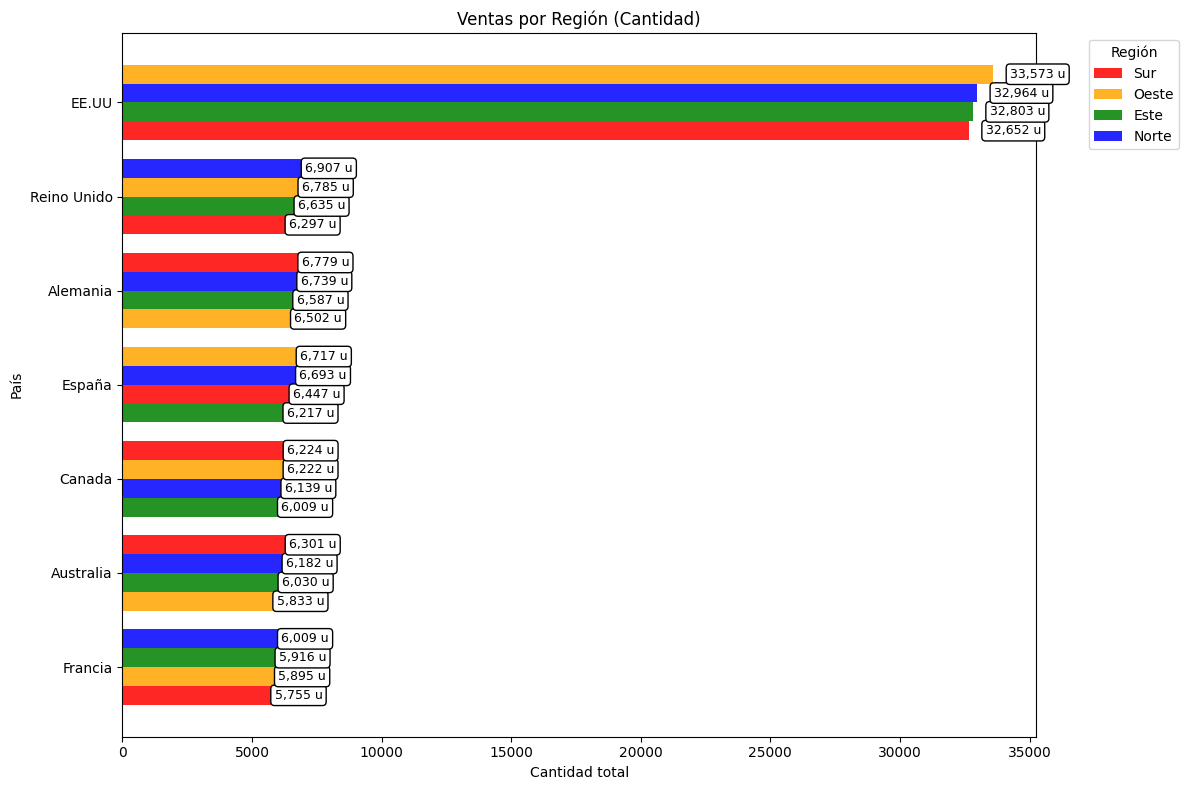

In [29]:
# Creo un grafico de barras para ver los resultados de paises y regiones con mas unidades vendidas

import matplotlib.pyplot as plt
import numpy as np

df = df_ventas_por_pais_region.copy()

paises = df['Pais'].unique()
regiones = df['Region'].unique()

colores = {
    regiones[0]: 'red',
    regiones[1]: 'orange',
    regiones[2]: 'green',
    regiones[3]: 'blue'
}

altura = 0.20  
plt.figure(figsize=(12, 8))

usadas_en_leyenda = set()

for i, pais in enumerate(paises):
    df_pais = (
        df[df['Pais'] == pais]
        .sort_values('Cantidad_Total', ascending=True) 
    )


    offsets = np.linspace(
        -altura * (len(df_pais) - 1) / 2,
        altura * (len(df_pais) - 1) / 2,
        len(df_pais)
    )

    for offset, (_, fila) in zip(offsets, df_pais.iterrows()):
        region = fila['Region']
        cantidad = fila['Cantidad_Total']

    
        color = colores.get(region, 'gray')

        plt.barh(
            i + offset,
            cantidad,
            height=altura,
            color=color,
            alpha=0.85,
            label=region if region not in usadas_en_leyenda else None
        )


        plt.text(
            cantidad + cantidad * 0.02,
            i + offset,
            f"{cantidad:,} u",
            va='center',
            fontsize=9,
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
        )

    usadas_en_leyenda.update(df_pais['Region'])

plt.yticks(range(len(paises)), paises)
plt.xlabel("Cantidad total")
plt.ylabel("País")
plt.title("Ventas por Región (Cantidad)")
plt.legend(title="Región", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()




8.3 Analisis por Ciudad

In [30]:
# 1. Creo un DataFrame para ver los paises y sus ciudades con la cantidad e importe de productos vendidos
df_ventas_por_pais_ciudad = (
    df_productos.groupby(['Pais', 'Ciudad'])
    .agg(
        Cantidad_Total=('Cantidad', 'sum'),
        Importe_Total=('Importe', 'sum')
    )
    .reset_index()
)

# 2. Ordeno los países por mayor cantidad total
totales_pais = (
    df_ventas_por_pais_ciudad.groupby('Pais')['Cantidad_Total']
    .sum()
    .sort_values(ascending=False)
)

# 3. Convierto la columna Pais en categórica con el orden correcto
df_ventas_por_pais_ciudad['Pais'] = pd.Categorical(
    df_ventas_por_pais_ciudad['Pais'],
    categories=totales_pais.index,
    ordered=True
)

# 4. Ordeno las ciudades dentro de cada país por mayor cantidad
df_ventas_por_pais_ciudad = df_ventas_por_pais_ciudad.sort_values(
    ['Pais', 'Cantidad_Total'],
    ascending=[True, False]
)

df_ventas_por_pais_ciudad


,Pais,Ciudad,Cantidad_Total,Importe_Total
5,EE.UU,Los Angeles,28437,2568888.16
3,EE.UU,Chicago,27681,2530931.18
7,EE.UU,Phoenix,25907,2373744.40
4,EE.UU,Houston,25221,2300530.40
6,EE.UU,New York,24746,2265153.74
10,Reino Unido,London,26624,2452641.47
0,Alemania,Berlin,26607,2403910.35
8,España,Madrid,26074,2393514.56
2,Canada,Toronto,24594,2177326.69
1,Australia,Sydney,24346,2261538.69


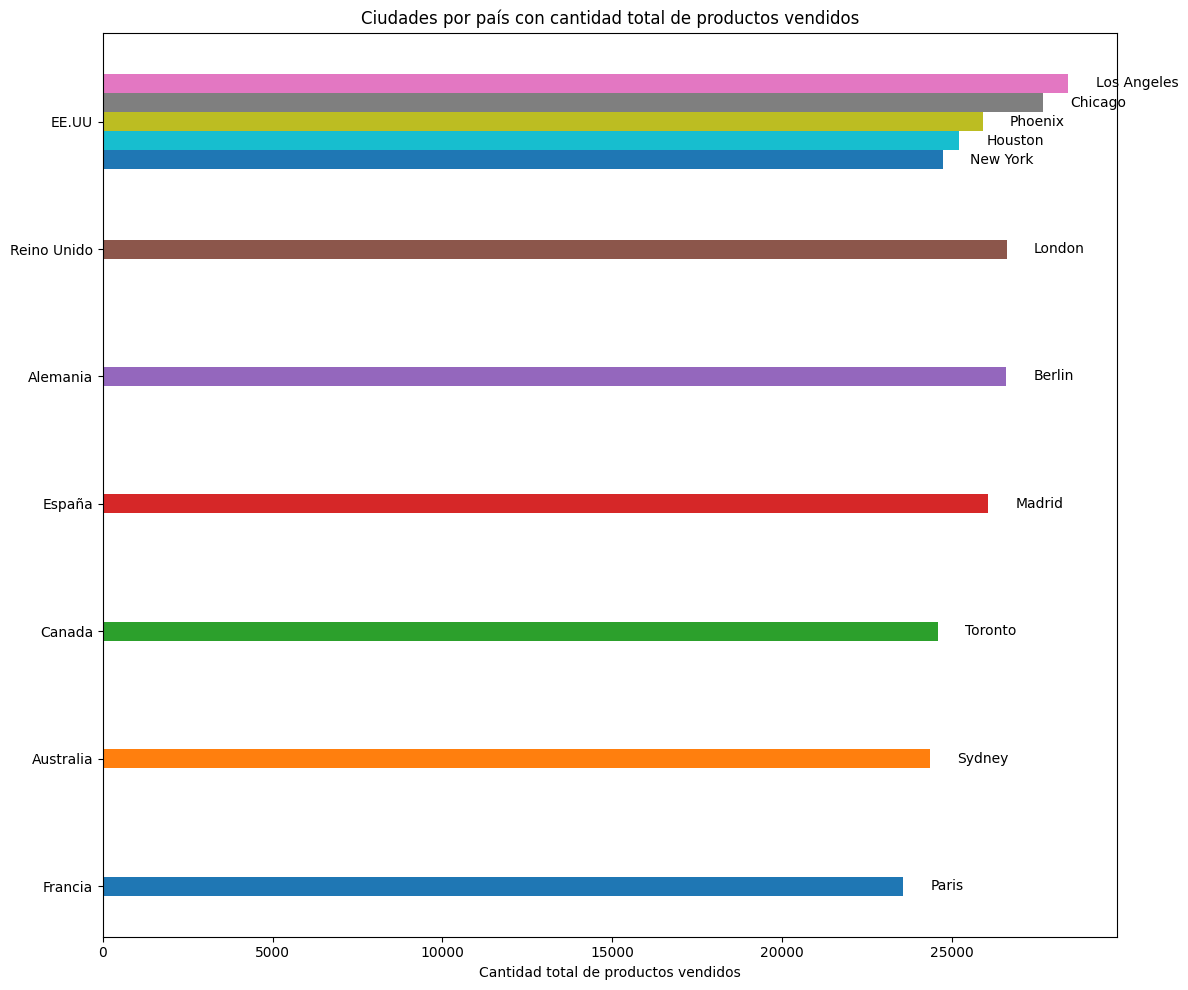

In [31]:
# Creo un grafico de barras los paises y sus ciudades con la cantidad e importe de productos vendidos

import matplotlib.pyplot as plt
import numpy as np

df = df_ventas_por_pais_ciudad.copy()

# Orden descendente de países (ya viene ordenado por totales)
paises = df['Pais'].cat.categories[::-1] 
num_paises = len(paises)

plt.figure(figsize=(12, 10))

height = 0.15
y = np.arange(num_paises)

for i, pais in enumerate(paises):

    subset = df[df["Pais"] == pais].sort_values("Cantidad_Total", ascending=False)
    num_ciudades = len(subset)

    start = y[i] - (height * (num_ciudades - 1) / 2)

    for j, row in enumerate(subset.itertuples()):
        pos_y = start + (num_ciudades - 1 - j) * height

        plt.barh(pos_y, row.Cantidad_Total, height=height)
        plt.text(row.Cantidad_Total + 800, pos_y, row.Ciudad,
                 va='center', fontsize=10)

plt.yticks(y, paises)

plt.title("Ciudades por país con cantidad total de productos vendidos")
plt.xlabel("Cantidad total de productos vendidos")

plt.tight_layout()
plt.show()


Conclusión: EEUU es el páis con más productos vendidos (131992 uds y 12039247.88
€). Su región que lidera las ventas el el Sur (33573 uds) con la ciudad principal de Los Angeles (28437 uds)

9. ANALISIS SOCIOECONOMICO

9.1 Analisis por Edad de Clientes

In [32]:
# Creo un DataFrame para ver los clientes con la cantidad e importe de productos vendidos por rango de edades

# Mediante un buckle for selecciono la columna de edad disponible
age_col = None
for col in ['age']:
    if col in df_analisis.columns:
        age_col = col
        break

if age_col is None:
    # La columna disponible en el DataFrame se llama "Edad"
    posibles_columnas_edad = ['Edad', 'edad', 'Age', 'age']

    age_col = next(
        (col for col in posibles_columnas_edad if col in df_analisis.columns),
        None
    )

    if age_col is None:
        raise ValueError(
            f"No se encontró una columna de edad. "
            f"Columnas disponibles: {list(df_analisis.columns)}"
        )

    df_analisis[age_col] = pd.to_numeric(
        df_analisis[age_col],
        errors='coerce'
    )

# Creo una lista con edades y sus rangos y una variable que divida una variable numérica en intervalos (bins) y le asigne una etiqueta a cada intervalo.
edades = [0, 25, 35, 45, 55, 65, 75, 120]
rangos = ['18-25', '26-35', '36-45', '46-55', '56-65', '66-75', '76+']

df_analisis['Rango de edad'] = pd.cut(
    df_analisis[age_col],
    bins=edades,
    labels=rangos,
    include_lowest=True,
    right=True
)

# Agrego una tabla con las columnas Rango de edad, Total, Cantidad de productos, Importe de ventas

analisis_edad = (
    df_analisis.groupby('Rango de edad', dropna=False)
    .agg(
        Total=('Rango de edad', 'count'),
        Cantidad_total=('Cantidad', 'sum'),
        Importe_total=('Importe', 'sum')
        
    )
    .reset_index()
)


# Compruebo el resultado
analisis_edad = analisis_edad.sort_values('Rango de edad').reset_index(drop=True)
analisis_edad



,Rango de edad,Total,Cantidad_total,Importe_total
0,18-25,6030,33089,2999884.44
1,26-35,7949,44118,3955107.94
2,36-45,7543,41902,3844766.76
3,46-55,10282,56702,5211338.28
4,56-65,7605,41488,3828612.23
5,66-75,7707,42989,3872537.57
6,76+,4230,23524,2159988.73


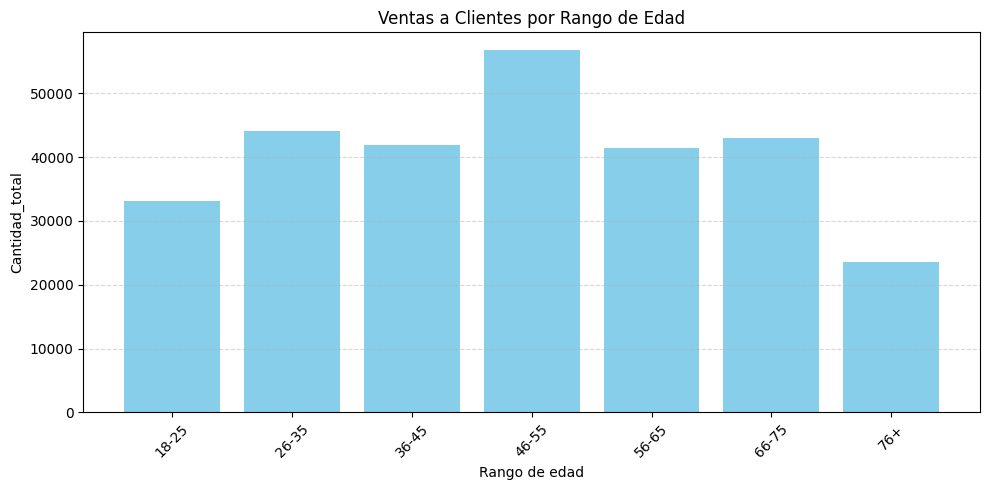

In [33]:
# Gráfico de columnas para mostrar las ventas de productos a clientes por rango de edad
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(analisis_edad['Rango de edad'], analisis_edad['Cantidad_total'], color='skyblue')
plt.title('Ventas a Clientes por Rango de Edad')
plt.xlabel('Rango de edad')
plt.ylabel('Cantidad_total')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Conclusión: Los clientes que más productos compran son los de rango de edad entre 46-55 años (56702 uds).

9.2 Analisis por Nivel de Ingresos

In [34]:

# Creo un DataFrame para ver los productos vendidos a clientes por su nivel de ingresos

analisis_nivel_ingresos = (
    df_analisis.groupby('Nivel_ingresos')
    .agg(
        Cantidad_total=('Cantidad', 'sum'),
        Importe_total=('Importe', 'sum')
        
    )
    .reset_index()
)

analisis_nivel_ingresos = analisis_nivel_ingresos.sort_values('Cantidad_total', ascending=False)

analisis_nivel_ingresos

,Nivel_ingresos,Cantidad_total,Importe_total
2,Medio,103113,9356474.27
0,Alto,93396,8561900.56
1,Bajo,87303,7953861.12


Conclusión: Los clientes con nivel de ingresos medios son los que más productos han comprado (103113 uds).

9.3 Analisis por Antiguedad

In [35]:

# Creo un DataFrame para ver los productos vendidos a clientes por su antiguedad
analisis_cliente_antiguedad = (
    df_analisis.groupby('Antiguedad')
    .agg(
        Cantidad_total=('Cantidad', 'sum'),
        Importe_total=('Importe', 'sum')
        
)
.reset_index()

)

analisis_cliente_antiguedad = analisis_cliente_antiguedad.sort_values('Cantidad_total', ascending=False)

analisis_cliente_antiguedad


,Antiguedad,Cantidad_total,Importe_total
4,8.0,41005,3748101.81
1,5.0,40836,3758353.28
3,7.0,40338,3664467.11
2,6.0,40325,3649833.98
6,10.0,40238,3683840.68
5,9.0,39738,3618115.65
7,11.0,33568,3034180.43
0,4.0,7764,715343.01


Conclusión: Los clientes con una antiguedad de 5 años son los que más han comprado (40803 uds).

9.4 Analisis por Genero

In [36]:
# Creo un DataFrame para ver los productos vendidos a clientes por su genero
analisis_cliente_genero = (
    df_analisis.groupby('Genero')
    .agg(
        Cantidad_total=('Cantidad', 'sum'),
        Importe_total=('Importe', 'sum')
        
)
.reset_index()

)

analisis_cliente_genero = analisis_cliente_genero.sort_values('Cantidad_total', ascending=False)

analisis_cliente_genero

,Genero,Cantidad_total,Importe_total
0,Hombre,145819,13336587.73
1,Mujer,137993,12535648.22


10. ANALISIS DE DISTRIBUCIÓN DE VENTAS POR RANGO DE VALOR, PAIS Y CANAL

In [37]:
# Agrupar ventas por producto, rango de valor, país, región, ciudad y canal
df_ventas_rango_valor_pais_canal= (
    df_analisis
    .groupby([
        'Producto',
        'Rango_valor_pedido',
        'Pais',
        'Region',
        'Ciudad',
        'Canal'
    ])
    .agg(
        Cantidad_Vendida=('Cantidad', 'sum'),
        Importe_Total=('Importe', 'sum')
    )
    .reset_index()
    .sort_values(['Pais', 'Region', 'Ciudad', 'Producto'])
)

df_ventas_rango_valor_pais_canal



,Producto,Rango_valor_pedido,Pais,Region,Ciudad,Canal,Cantidad_Vendida,Importe_Total
0,Dispositivo A,Alto,Alemania,Este,Berlin,En Linea,88,10903.64
1,Dispositivo A,Alto,Alemania,Este,Berlin,En Tienda,84,10631.00
2,Dispositivo A,Alto,Alemania,Este,Berlin,M-Commerce,54,6645.76
3,Dispositivo A,Alto,Alemania,Este,Berlin,Minorista,67,8846.62
176,Dispositivo A,Bajo,Alemania,Este,Berlin,En Linea,19,139.54
...,...,...,...,...,...,...,...,...
4979,Dispositivo J,Bajo,Reino Unido,Sur,London,Minorista,43,357.65
5152,Dispositivo J,Medio,Reino Unido,Sur,London,En Linea,91,3511.40
5153,Dispositivo J,Medio,Reino Unido,Sur,London,En Tienda,67,4232.17
5154,Dispositivo J,Medio,Reino Unido,Sur,London,M-Commerce,92,4941.68


([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'Alemania'),
  Text(1, 0, 'Australia'),
  Text(2, 0, 'Canada'),
  Text(3, 0, 'EE.UU'),
  Text(4, 0, 'España'),
  Text(5, 0, 'Francia'),
  Text(6, 0, 'Reino Unido')])

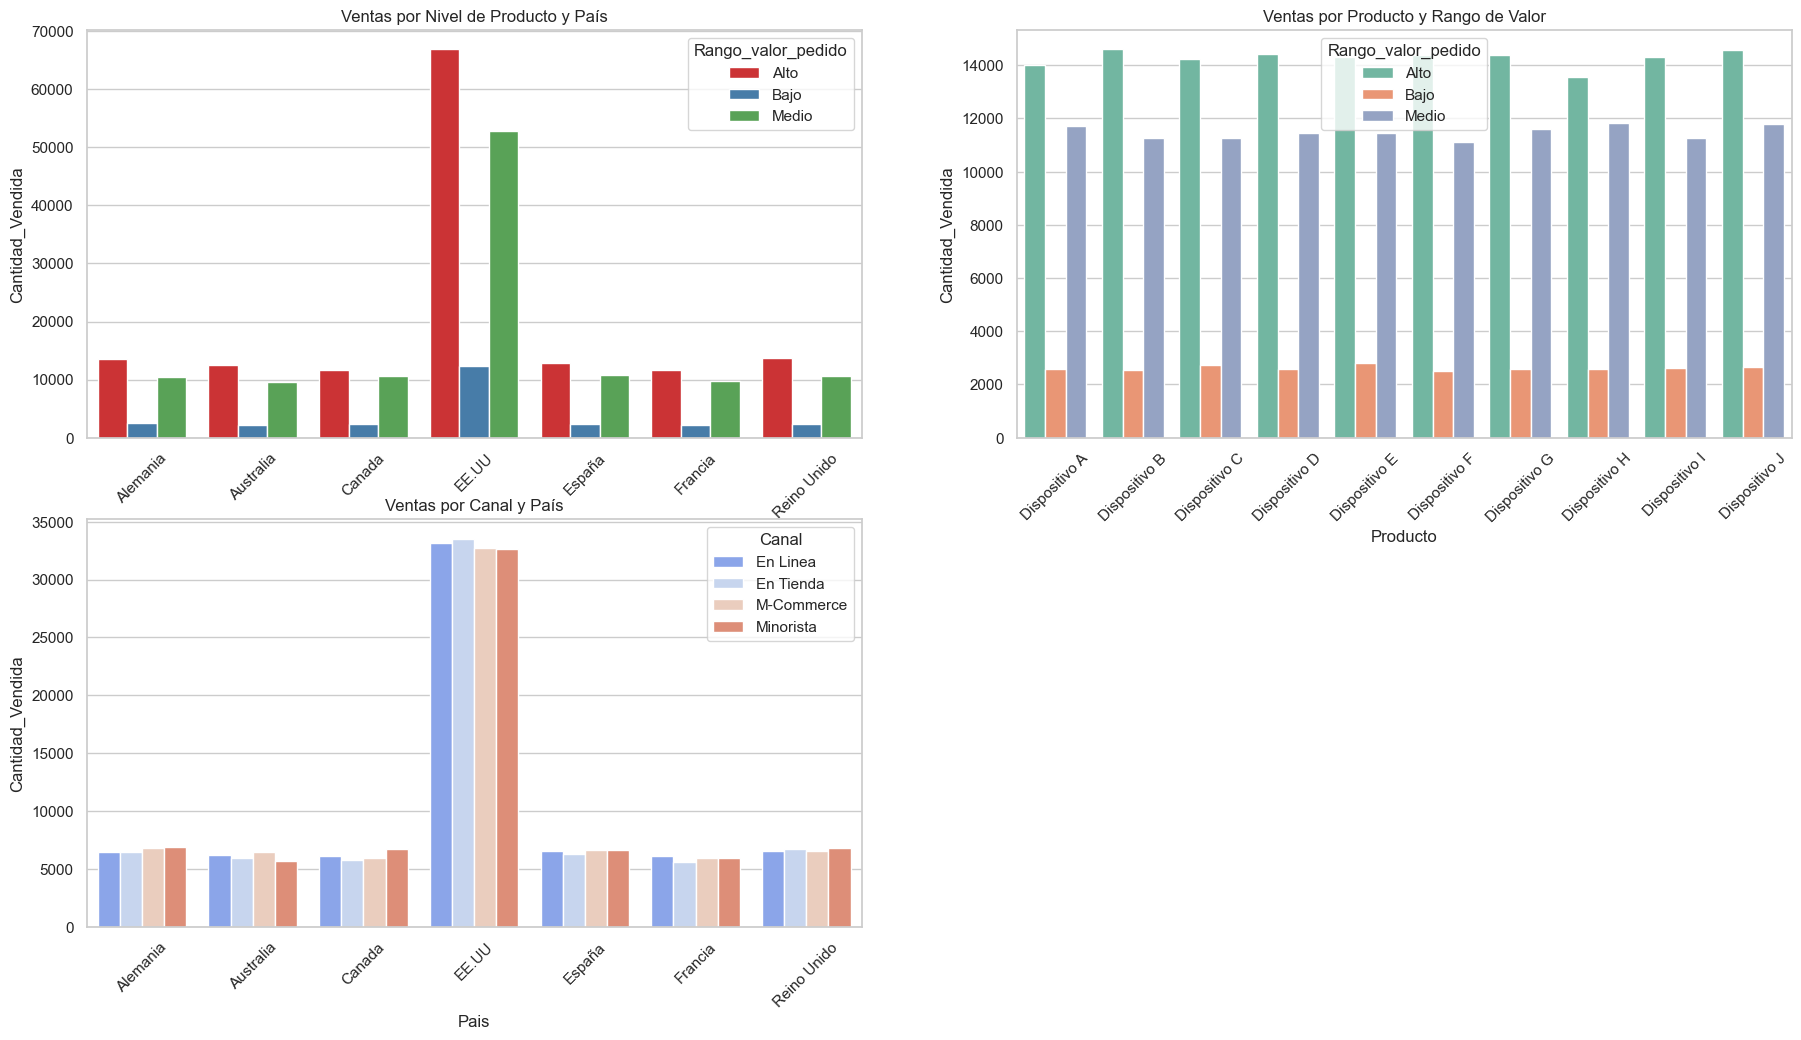

In [38]:
# Muestro los datos en un Dashboard

import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# 1. Preparación del dataset
# ============================

df_dash = (
    df_analisis
    .groupby([
        'Producto',
        'Rango_valor_pedido',
        'Pais',
        'Region',
        'Ciudad',
        'Canal'
    ])
    .agg(
        Cantidad_Vendida=('Cantidad', 'sum'),
        Importe_Vendido=('Importe', 'sum'),
        Num_Transacciones=('Id_venta', 'count')
    )
    .reset_index()
)

# ============================
# 2. Configuración general
# ============================

sns.set(style="whitegrid")
plt.figure(figsize=(22, 18))


# ============================
# Gráfico 1 : Ventas por Nivel y País
# ============================

plt.subplot(3, 2, 1)
nivel_pais = (
    df_dash.groupby(['Pais', 'Rango_valor_pedido'])['Cantidad_Vendida']
    .sum()
    .reset_index()
)

sns.barplot(
    data=nivel_pais,
    x='Pais',
    y='Cantidad_Vendida',
    hue='Rango_valor_pedido',
    palette='Set1'
)
plt.title("Ventas por Nivel de Producto y País")
plt.xticks(rotation=45)


# ============================
# Gráfico 2: Ventas por producto y rango
# ============================

plt.subplot(3, 2, 2)
sns.barplot(
    data=df_dash.groupby(['Producto', 'Rango_valor_pedido'])['Cantidad_Vendida'].sum().reset_index(),
    x='Producto',
    y='Cantidad_Vendida',
    hue='Rango_valor_pedido',
    palette='Set2'
)
plt.title("Ventas por Producto y Rango de Valor")
plt.xticks(rotation=45)


# ============================
# Gráfico 3: Ventas por Canal y País
# ============================

plt.subplot(3, 2, 3)
canal_pais = (
    df_dash.groupby(['Pais', 'Canal'])['Cantidad_Vendida']
    .sum()
    .reset_index()
)

sns.barplot(
    data=canal_pais,
    x='Pais',
    y='Cantidad_Vendida',
    hue='Canal',
    palette='coolwarm'
)
plt.title("Ventas por Canal y País")
plt.xticks(rotation=45)



Conclusión:
1. Los productos con rango alto de nivel son los mas vendidos en todos los paises.
2. Los productos de gama media‑alta (Dispositivo B, E, G…) concentran entre 70% y 80% de sus ventas en rangos Medio y Alto.
3.El canal más utilizado para las ventas es En Linea.